# Aiyagari with Endogenous Labor Supply — General Equilibrium Incomplete Markets

**How does endogenous labor supply interact with precautionary savings when households adjust both savings and work hours?** In baseline Aiyagari (1994), labor supply is inelastic ($h=1$), so idiosyncratic productivity shocks translate directly into income risk. When households can adjust work hours $h(a, z)$, low-wealth households work more to self-insure against bad shocks (a negative wealth effect on labor supply), while high-wealth households consume more leisure. This notebook solves the **Aiyagari general equilibrium model with endogenous labor supply** using `puremacro.vfi.aiyagari_endogenous.solve_aiyagari_endogenous`, demonstrating market clearing in capital ($K$) and labor ($L$).

## The method in math — Intra-temporal Labor Choice & GE Market Clearing

Households solve:
$$ V(a, z) = \max_{a' \ge 0, h \in [0, 1]} \left\{ \frac{c^{1-\sigma}}{1-\sigma} - \chi \frac{h^{1+1/\nu}}{1+1/\nu} + \beta \sum_{z'} P(z, z') V(a', z') \right\} $$
subject to:
$$ c + a' = (1+r)a + w \cdot z \cdot h $$
Firm Cobb-Douglas technology $Y = A K^\alpha L^{1-\alpha}$ determines factor prices:
$$ r = \alpha A (K/L)^{\alpha - 1} - \delta, \qquad w = (1-\alpha) A (K/L)^\alpha $$
**General Equilibrium.** A stationary equilibrium requires factor prices $(r^*, w^*)$ such that aggregate capital demand equals aggregate household asset holdings $K = \int a \, d\mu(a, z)$ and aggregate labor demand equals aggregate labor supply $L = \int z \cdot h(a, z) d\mu(a, z)$.

## Setup — solving the GE endogenous labor model

We solve for equilibrium factor prices $(r^*, w^*)$, optimal policy functions $a'(a, z)$ and $h(a, z)$, and aggregate quantities $(K^*, L^*)$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi.aiyagari_endogenous import solve_aiyagari_endogenous

# Solve Aiyagari GE with endogenous labor supply
results = solve_aiyagari_endogenous(
    beta=0.95,
    gamma=2.0,
    frisch=0.5,
    chi=1.2,
    alpha=0.36,
    delta=0.08,
    rho_e=0.90,
    sigma_e=0.20,
    Na=45,
    Ne=5,
    r_guess=0.035
)

r_star = results["r_star"]
w_star = results["w_star"]
K_star = results["K_star"]
L_star = results["L_star"]
grid_a = results["a_grid"]
e_grid = results["e_grid"]
policy_n = results["policy_n"] # Labor policy: shape (Na, Ne)
policy_a = results["policy_a"]

print(f"Equilibrium Net Interest Rate r*: {r_star:.4f}")
print(f"Equilibrium Wage Rate w*: {w_star:.4f}")
print(f"Aggregate Capital K*: {K_star:.4f}")
print(f"Aggregate Labor L*: {L_star:.4f}")
print(f"Capital-Labor Ratio K/L: {(K_star / L_star):.4f}")

# Headline assertions
assert r_star < 1/0.95 - 1.0, f"r* must be strictly below 1/beta - 1: {r_star}"
assert K_star > 0.0 and L_star > 0.0, "Aggregate factors must be positive"
assert policy_n.shape == (45, 5), "Labor policy shape mismatch"

Equilibrium Net Interest Rate r*: 0.0350
Equilibrium Wage Rate w*: 1.2161
Aggregate Capital K*: 6.6284
Aggregate Labor L*: 1.0636
Capital-Labor Ratio K/L: 6.2318


## Hero Figure — Endogenous labor supply policy rules n(a, e)

We plot optimal labor supply $n(a, e)$ across wealth levels $a$ for different productivity states $e$.

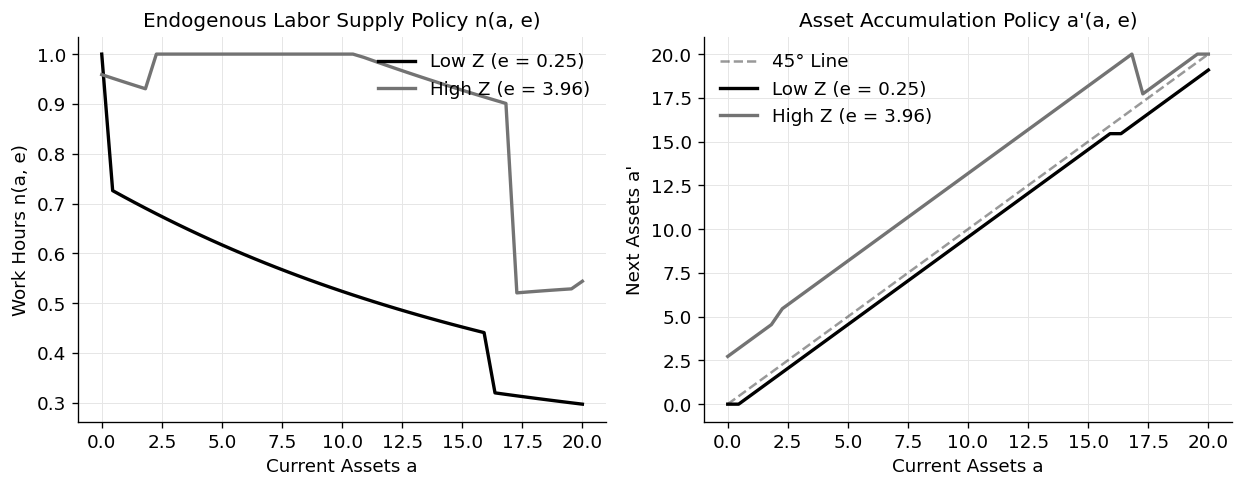

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Left Panel: Endogenous labor policy n(a, e)
ax1.plot(grid_a, policy_n[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Low Z (e = {e_grid[0]:.2f})")
ax1.plot(grid_a, policy_n[:, -1], color=_nbstyle.palette(2)[1], lw=2, label=f"High Z (e = {e_grid[-1]:.2f})")
ax1.set_xlabel("Current Assets a")
ax1.set_ylabel("Work Hours n(a, e)")
ax1.set_title("Endogenous Labor Supply Policy n(a, e)")
ax1.legend(loc="upper right")

# Right Panel: Asset policy a'(a, e)
ax1_line = np.linspace(0, grid_a[-1], 100)
ax2.plot(ax1_line, ax1_line, "k--", alpha=0.4, label="45° Line")
ax2.plot(grid_a, policy_a[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Low Z (e = {e_grid[0]:.2f})")
ax2.plot(grid_a, policy_a[:, -1], color=_nbstyle.palette(2)[1], lw=2, label=f"High Z (e = {e_grid[-1]:.2f})")
ax2.set_xlabel("Current Assets a")
ax2.set_ylabel("Next Assets a'")
ax2.set_title("Asset Accumulation Policy a'(a, e)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Reading the output.** Work hours $n(a, e)$ decline with wealth $a$ due to the negative wealth effect: poorer households work longer hours to buffer against income risk, whereas wealthier households choose leisure. High-productivity households ($e_{\max}$) work more than low-productivity households at all wealth levels due to the positive substitution effect of higher wages.

## Your turn — Frisch elasticity and labor market responsiveness

**Prompts.**
1. *Basic*: Increase Frisch elasticity from `frisch = 0.5` to `frisch = 0.8` (`# ← change this ...`). Does labor supply become more sensitive to wealth levels?
2. *Intermediate*: Increase disutility of labor parameter `chi = 2.0` and observe the decrease in aggregate labor supply $L^*$.
3. *Stretch*: Compare aggregate capital $K^*$ between lower and higher labor supply elasticity.

In [3]:
# Your turn code block
frisch_yt = 0.8  # ← change this: try 0.8 or 1.0

res_yt = solve_aiyagari_endogenous(
    beta=0.95,
    gamma=2.0,
    frisch=frisch_yt,
    chi=1.2,
    alpha=0.36,
    delta=0.08,
    rho_e=0.90,
    sigma_e=0.20,
    Na=40,
    Ne=5
)

print(f"New Frisch Elasticity frisch = {frisch_yt:.2f}")
print(f"New Equilibrium r*: {res_yt['r_star']:.4f}")
print(f"New Aggregate Labor L*: {res_yt['L_star']:.4f}")

# Assertion holding for default
assert res_yt["K_star"] > 0.0, "Aggregate capital must be positive"

New Frisch Elasticity frisch = 0.80
New Equilibrium r*: 0.0350
New Aggregate Labor L*: 0.9676


## How comprehensive is this?

`puremacro.vfi.aiyagari_endogenous` provides the GE incomplete-markets solver with flexible intra-temporal labor optimization, connecting directly to Heterogeneous Agent New Keynesian (HANK) models and `puremacro.vfi` distribution routines.